In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import bte


Notebook to visualise MOV clusters with singletons from UShER phylogenies. MOV-like nodes are defined as nodes with LLRs > 3 and sum_contexts > 2.

In [3]:
df = pd.read_csv("/Users/reem/merged_bte_mov_strict.tsv", sep="\t")
df.head()

,Unnamed: 0,node_id,parent_id,children,mutations,num_mutations,LLR,sum_llrs,sum_contexts,country,cluster_size,size_bin,year
0,0,Tanzania/NIMR-R40128/2021|EPI_ISL_19837217|202...,node_24835,[],"'C1758T', 'C7600T', 'G8984A', 'C11200T', 'C166...",13,4.774250,7.027866,2.253616,Tanzania,1.0,1,2021
1,1,India/KA-042197_2_S61_R1_001/2020|EPI_ISL_1708...,node_243043,[],"'C8299T', 'C10369T', 'C10714T', 'C12528T', 'C1...",9,3.925618,6.601791,2.676172,India,1.0,1,2020
2,2,Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|...,node_243370,[],"'C676T', 'C1387T', 'C5986T', 'G8990A', 'C9487T...",10,3.672689,6.405349,2.732660,Mexico,1.0,1,2020
3,3,USA/MA-CDC-LC0049944/2021|EPI_ISL_1926374|2021...,node_254525,[],"'C2110T', 'C6954T', 'T7984C', 'C8809T', 'C8890...",10,3.465710,5.982177,2.516467,USA,1.0,1,2021
4,4,hCoV-19/Australia/WA6668/2022|2022-08-19|2022-...,node_543775,[],"'G428A', 'G1156A', 'C1282T', 'G1358A', 'T1792C...",61,9.789147,21.424638,11.635491,NaN,1.0,1,2022


In [4]:
tree = bte.MATree(pb_file="/Users/reem/2026_updated_tree.pb")


Finished 'from_pb' in 468.0948 seconds


In [7]:
# Plot Mov Clusters

bins = [1,2,4,8,16,32]
labels = ["1","2-3","4-7","8-15","16-30"]

df["size_bin"] = pd.cut(df["cluster_size"], bins=bins, right=False, labels=labels)

dist = df.groupby("size_bin").size().reset_index(name="n_clusters")

fig = px.bar(dist, x="size_bin", y="n_clusters", text="n_clusters", orientation="v")
fig.update_layout(
    xaxis_title="Number of MOV clusters",
    yaxis_title="MOV cluster size (log scale)",
    title="Distribution of MOV clusters vs Number of Descendants"
)
fig.update_traces(width=0.8, textposition="outside") 
fig.update_yaxes(type="log")
fig.show()


/var/folders/bt/jpy5j9ms7pb6p6hhqzvpjffw0000gn/T/ipykernel_91929/3761621930.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [8]:
# save as svg
fig.write_image("/Users/reem/new_figs/distribution_of_mov_clusters.svg")

In [9]:
# Plot MOV clusters per country, collapse singletons into "Other"

country_counts = df["country"].str.strip().value_counts().reset_index()
country_counts.columns = ["country", "n_clusters"]

# Excluding singletons from the plot, but keeping them in the dataframe for accurate counts
# country_counts = country_counts[country_counts["n_clusters"] >2]
country_counts.loc[country_counts["n_clusters"] <= 2, "country"] = "Other"
# country_counts = country_counts.groupby("country")["n_clusters"].sum().reset_index()
            
fig = px.bar(
    country_counts.sort_values(by="n_clusters", ascending=True),
    x="n_clusters", y="country",
    orientation="h",
    title="Number of MOV clusters per country"
)
fig.update_layout(xaxis_title="Number of MOV clusters", yaxis_title="Country", height=1000)
fig.show()



In [10]:
fig.write_image("/Users/reem/new_figs/distribution_of_mov_per_country.svg")

In [11]:
year_counts = df["year"].value_counts().reset_index()
year_counts.columns = ["year", "num_mov_clusters"]
year_counts.sort_values(by="year")
fig = px.bar(
    year_counts.sort_values(by="year"),
    x="year", y="num_mov_clusters",
    title="Number of MOV clusters per year",
    color_discrete_sequence=["indianred"]
    
    )
fig.update_layout(xaxis_title="Year", yaxis_title="Number of MOV clusters")
fig.show()

In [12]:
fig.write_image("/Users/reem/new_figs/mov_clusters_per_year.svg")

In [ ]:
import tqdm
iterator = pd.read_csv("/Users/reem/gisaidAndPublic.2026-01-26.gisaidNames.metadata.tsv.gz", sep="\t", chunksize=10000)
metadata = pd.concat([chunk for chunk in tqdm.tqdm(iterator)], ignore_index=True)
print(len(metadata))
print(metadata.head())

In [ ]:
# Extract year from date col in metadata, replace "?" with NaN first
metadata["date"] = metadata["date"].replace("?", np.nan)
metadata['Year'] = pd.DatetimeIndex(metadata['date']).year

metadata["Year"].head()

In [ ]:
# Get the total number of sequence per year from Gisaid metadata, and save to a tsv
metadata["Year"] = pd.to_numeric(metadata["Year"], errors="coerce").astype("Int64")
metadata["Year"] = metadata["Year"].fillna(0).astype(int) 

#Remove years with very low counts (before 2019)
year_counts = metadata["Year"].value_counts().reset_index()
year_counts.columns = ["year", "count"]
year_counts = year_counts[year_counts["year"] >= 2019]
year_counts.sort_values(by="year", inplace=True)
i = year_counts[year_counts["year"] < 2019].index
year_counts.drop(i, axis=0, inplace=True)

In [ ]:
# Save value counts of years to a csv
year_counts.to_csv("/Users/reem/total_seqs_per_year.tsv",sep="\t", index=False)


In [13]:
year_counts = pd.read_csv("/Users/reem/total_seqs_per_year.tsv", sep="\t")

year_counts

,year,count
0,2019,50
1,2020,814241
2,2021,7341360
3,2022,6743816
4,2023,1549182
5,2024,580755
6,2025,213102
7,2026,1103


In [14]:
# Num Mov clusters per year
mov_counts_per_year = df["year"].value_counts().reset_index()
mov_counts_per_year.columns = ["year", "n_clusters"]
mov_counts_per_year.sort_values(by="year", inplace=True)
mov_counts_per_year

,year,n_clusters
5,2020,2
3,2021,16
0,2022,560
1,2023,329
2,2024,78
4,2025,16


In [16]:
plotly_df = pd.merge(year_counts, mov_counts_per_year, on="year", how="left").fillna(0)
plotly_df

,year,count,n_clusters
0,2019,50,0.0
1,2020,814241,2.0
2,2021,7341360,16.0
3,2022,6743816,560.0
4,2023,1549182,329.0
5,2024,580755,78.0
6,2025,213102,16.0
7,2026,1103,0.0


In [ ]:
# MOV_Clusters per year Normalized by total sequences per year
plotly_df["mov_normalized"] = (plotly_df["n_clusters"] / plotly_df["count"]) *1e6


fig = px.bar(
    plotly_df.sort_values(by="year"),
    x="year", y="mov_normalized",
    title="Number of MOV clusters normalized by total sequences per year",
    color_discrete_sequence=["indianred"]
    
    )
fig.update_layout(xaxis_title="Year", yaxis_title="Number of MOV clusters per million sequences")
fig.show()

In [18]:
fig.write_image("/Users/reem/new_figs/mov_clusters_per_year_normalized.svg")

In [19]:
mov_counts_per_year

,year,n_clusters
5,2020,2
3,2021,16
0,2022,560
1,2023,329
2,2024,78
4,2025,16


In [20]:
# Mov Percentage per year

year_totals = mov_counts_per_year.merge(year_counts, on="year")

year_totals["mov_percentage"] = (year_totals["n_clusters"] / year_totals["count"]) * 100

year_totals


fig = px.bar(
    year_totals.sort_values(by="year"),
    x="year", y="mov_percentage",
    title="Percentage of MOV clusters per year",
    color_discrete_sequence=["purple"]
    
    )
fig.update_layout(xaxis_title="Year", yaxis_title="Percentage of MOV clusters (%)")
fig.show()


In [21]:
fig.write_image("/Users/reem/new_figs/percent_mov_clusters_per_year.svg")

In [23]:
df.head()

,Unnamed: 0,node_id,parent_id,children,mutations,num_mutations,LLR,sum_llrs,sum_contexts,country,cluster_size,size_bin,year
0,0,Tanzania/NIMR-R40128/2021|EPI_ISL_19837217|202...,node_24835,[],"'C1758T', 'C7600T', 'G8984A', 'C11200T', 'C166...",13,4.774250,7.027866,2.253616,Tanzania,1.0,1,2021
1,1,India/KA-042197_2_S61_R1_001/2020|EPI_ISL_1708...,node_243043,[],"'C8299T', 'C10369T', 'C10714T', 'C12528T', 'C1...",9,3.925618,6.601791,2.676172,India,1.0,1,2020
2,2,Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|...,node_243370,[],"'C676T', 'C1387T', 'C5986T', 'G8990A', 'C9487T...",10,3.672689,6.405349,2.732660,Mexico,1.0,1,2020
3,3,USA/MA-CDC-LC0049944/2021|EPI_ISL_1926374|2021...,node_254525,[],"'C2110T', 'C6954T', 'T7984C', 'C8809T', 'C8890...",10,3.465710,5.982177,2.516467,USA,1.0,1,2021
4,4,hCoV-19/Australia/WA6668/2022|2022-08-19|2022-...,node_543775,[],"'G428A', 'G1156A', 'C1282T', 'G1358A', 'T1792C...",61,9.789147,21.424638,11.635491,NaN,1.0,1,2022


In [32]:
df = pd.read_csv("/Users/reem/merged_bte_final.tsv", sep="\t")

In [34]:
df.head()

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,A>G_llr,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts,country,date,num_descendants
0,Yunnan/0306-466/2020|EPI_ISL_429239|2020-03-06,node_1,[],'G15910T',1,2,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,China,2020,1
1,Japan/DP0803/2020|EPI_ISL_416630|2020-02-17,node_1,[],'G4162T',1,2,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,NaN,2020,1
2,node_2,node_1,['England/LEED-2A8B52/2020|EPI_ISL_539074|2020...,'T13090C',1,2,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,2
3,England/LEED-2A8B52/2020|EPI_ISL_539074|2020-0...,node_2,[],"'C1191T', 'C11674T'",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360,...,0.0,"Counter({'C[C>T]A': 1, 'A[C>T]T': 1})",-0.351044,Counter(),0.000000,0.521315,-0.351044,England,2020,1
4,England/SHEF-C06CE/2020|EPI_ISL_420245|2020-03-25,node_2,[],'T15821C',1,3,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,1


In [46]:
# Functon to extract proportion of mov_seqs per country per year
def plot_mov_proportion(df, country):
    df_country = df[df["country"] == country]
    total_seqs = df_country["date"].value_counts().reset_index()
    mov_seqs = df_country[(df_country["LLR"]>3) & (df_country["sum_contexts"]>2)]["date"].value_counts().reset_index()
    #mov_seqs = df_country[df_country["sum_llrs"]>6]["date"].value_counts().reset_index()
    merged = total_seqs.merge(mov_seqs, on=total_seqs.columns[0], how="left").fillna(0)
    merged.columns = ["date", "total_seqs", "mov_seqs"]
    merged["proportion_mov"] = (merged["mov_seqs"] / merged["total_seqs"]) * 100
    merged = merged[merged["date"] != "0"].astype({"date": str})

    fig = px.bar(merged.sort_values(by="date"),
        x="date", y="proportion_mov",
        title=f"Percentage of MOV sequences per year in {country}",
        color_discrete_sequence=["teal"]
    )
    fig.update_layout(xaxis_title="Year", yaxis_title="Percentage of MOV sequences (%)")
    fig.update_yaxes(range=[0, 0.4])
    fig.show()
    #fig.write_image(f"/Users/reem/{country}_MOV_Proportion_per_Year.svg")
    return merged


#plot_mov_proportion(df, country="Australia")      
plot_mov_proportion(df, country="Japan")

,date,total_seqs,mov_seqs,proportion_mov
0,2022,158382,47.0,0.029675
1,2021,67958,0.0,0.000000
2,2023,62592,66.0,0.105445
3,2024,22498,24.0,0.106676
4,2020,9339,0.0,0.000000
5,2025,5281,1.0,0.018936
6,0,69,0.0,0.000000
7,2026,4,0.0,0.000000


In [47]:
# Same but grouped barplot. France is barely visible
rows = []
Years = [2020, 2021, 2022, 2023, 2024, 2025]
for year in Years:
    df_yr = df[df["date"]==year]
    Mov_pred = (df_yr["LLR"] > 3) & (df_yr["sum_contexts"] > 2)
    rows.append({
        "Australia_prop": Mov_pred[df_yr["country"]=="Australia"].sum()/len(df_yr[df_yr["country"]=="Australia"])*100,
        "France_prop": Mov_pred[df_yr["country"]=="France"].sum()/len(df_yr[df_yr["country"]=="France"])*100,
        "year": year,
    })
plotly_df = pd.DataFrame(rows)  

fig = px.bar(plotly_df, x="year", y=["Australia_prop", "France_prop"],
             barmode = 'group')
fig.update_layout(xaxis_title="Year", yaxis_title="Percentage of MOV sequences")


fig.show() 
fig.write_image("/Users/reem/mov_proportion_aus_france.svg")                         

In [48]:
plotly_df

,Australia_prop,France_prop,year
0,0.000000,0.000000,2020
1,0.000000,0.000000,2021
2,0.304035,0.000673,2022
3,0.390539,0.004988,2023
4,0.194081,0.000000,2024
5,0.067213,0.000000,2025


In [49]:
df_mov = pd.read_csv("/Users/reem/merged_bte_mov_strict.tsv", sep="\t")
df_mov.head()

,Unnamed: 0,node_id,parent_id,children,mutations,num_mutations,LLR,sum_llrs,sum_contexts,country,cluster_size,size_bin,year
0,0,Tanzania/NIMR-R40128/2021|EPI_ISL_19837217|202...,node_24835,[],"'C1758T', 'C7600T', 'G8984A', 'C11200T', 'C166...",13,4.774250,7.027866,2.253616,Tanzania,1.0,1,2021
1,1,India/KA-042197_2_S61_R1_001/2020|EPI_ISL_1708...,node_243043,[],"'C8299T', 'C10369T', 'C10714T', 'C12528T', 'C1...",9,3.925618,6.601791,2.676172,India,1.0,1,2020
2,2,Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|...,node_243370,[],"'C676T', 'C1387T', 'C5986T', 'G8990A', 'C9487T...",10,3.672689,6.405349,2.732660,Mexico,1.0,1,2020
3,3,USA/MA-CDC-LC0049944/2021|EPI_ISL_1926374|2021...,node_254525,[],"'C2110T', 'C6954T', 'T7984C', 'C8809T', 'C8890...",10,3.465710,5.982177,2.516467,USA,1.0,1,2021
4,4,hCoV-19/Australia/WA6668/2022|2022-08-19|2022-...,node_543775,[],"'G428A', 'G1156A', 'C1282T', 'G1358A', 'T1792C...",61,9.789147,21.424638,11.635491,NaN,1.0,1,2022


In [51]:
df_plot = df_mov[["year","cluster_size"]].value_counts().reset_index()
df_plot.columns = ["year", "cluster_size", "n_clusters"]
df_plot.sort_values(by="year", inplace=True)
df_plot

,year,cluster_size,n_clusters
15,2020,1.0,2
25,2021,5.0,1
8,2021,1.0,13
17,2021,2.0,2
0,2022,1.0,459
24,2022,8.0,1
3,2022,2.0,63
6,2022,3.0,14
7,2022,4.0,14
20,2022,9.0,1


<Axes: xlabel='year', ylabel='cluster_size'>

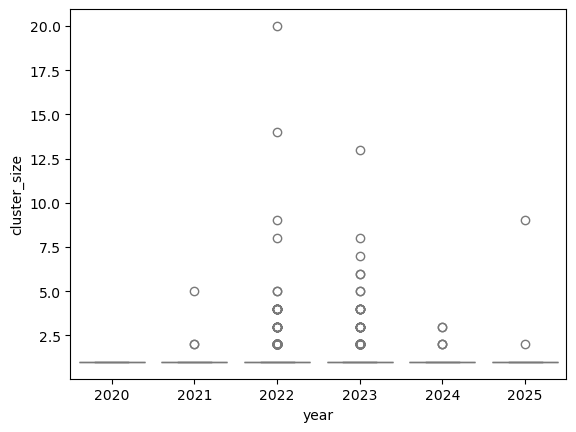

In [52]:
sns.boxplot(
    data=df_mov,
    x="year",
    y="cluster_size",
    
     color="lightblue"
)

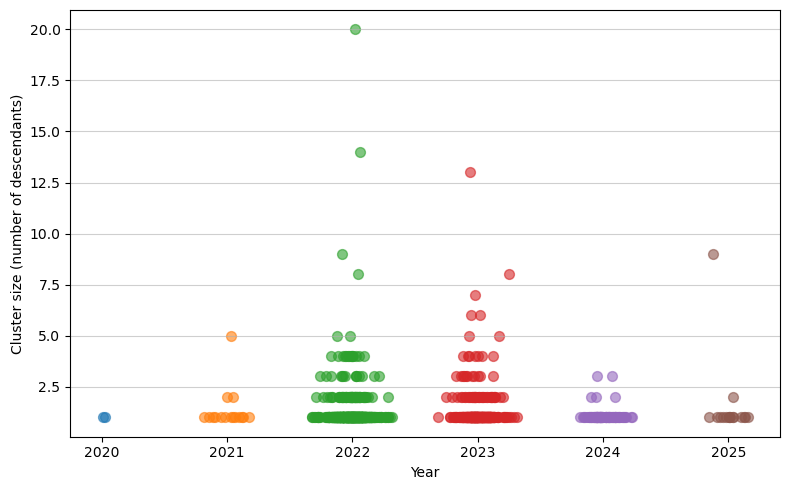

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

# Expand data: create one row per count
rows = []
for _, row in df_plot.iterrows():
    for i in range(int(row['n_clusters'])):
        rows.append({'Year': row['year'], 'Cluster size': row['cluster_size']})
        
df_expanded = pd.DataFrame(rows)

# Plot
plt.figure(figsize=(8, 5))
for year in df_expanded['Year'].unique():
    data = df_expanded[df_expanded['Year'] == year]
    x = data['Year'] + np.random.normal(0, 0.1, len(data))
    y = data['Cluster size'] 
    plt.scatter(x, y, alpha=0.6, s=50)
 

plt.xlabel('Year')
plt.ylabel('Cluster size (number of descendants)')
plt.grid(axis='y', alpha=0.6)
plt.tight_layout()
plt.show()



In [55]:
plt.savefig("/Users/reem/new_figs/mov_cluster_size_per_year.svg")

<Figure size 640x480 with 0 Axes>